In [ ]:
import pandas as pd
file = "EduPro Online Platform.xlsx"

users = pd.read_excel(file, sheet_name = "Users")
courses = pd.read_excel(file, sheet_name = "Courses")
transactions = pd.read_excel(file, sheet_name = "Transactions")
teachers = pd.read_excel(file, sheet_name = "Teachers")

In [ ]:
users.head()
courses.head()
transactions.head()
teachers.head()


,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11


In [ ]:
users.info()
users.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   UserID    3000 non-null   object
 1   UserName  3000 non-null   object
 2   Age       3000 non-null   int64 
 3   Gender    3000 non-null   object
 4   Email     3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB


,0
UserID,0
UserName,0
Age,0
Gender,0
Email,0


In [ ]:
courses.info()
courses.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CourseID        60 non-null     object 
 1   CourseName      60 non-null     object 
 2   CourseCategory  60 non-null     object 
 3   CourseType      60 non-null     object 
 4   CourseLevel     60 non-null     object 
 5   CoursePrice     60 non-null     float64
 6   CourseDuration  60 non-null     float64
 7   CourseRating    60 non-null     float64
dtypes: float64(3), object(5)
memory usage: 3.9+ KB


,0
CourseID,0
CourseName,0
CourseCategory,0
CourseType,0
CourseLevel,0
CoursePrice,0
CourseDuration,0
CourseRating,0


In [ ]:
transactions.info()
transactions.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TransactionID    10000 non-null  object        
 1   UserID           10000 non-null  object        
 2   CourseID         10000 non-null  object        
 3   TransactionDate  10000 non-null  datetime64[ns]
 4   Amount           10000 non-null  float64       
 5   PaymentMethod    10000 non-null  object        
 6   TeacherID        10000 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 547.0+ KB


,0
TransactionID,0
UserID,0
CourseID,0
TransactionDate,0
Amount,0
PaymentMethod,0
TeacherID,0


In [ ]:
teachers.info()
teachers.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TeacherID          60 non-null     object 
 1   TeacherName        60 non-null     object 
 2   Age                60 non-null     int64  
 3   Gender             60 non-null     object 
 4   Expertise          60 non-null     object 
 5   YearsOfExperience  60 non-null     int64  
 6   TeacherRating      60 non-null     float64
dtypes: float64(1), int64(2), object(4)
memory usage: 3.4+ KB


,0
TeacherID,0
TeacherName,0
Age,0
Gender,0
Expertise,0
YearsOfExperience,0
TeacherRating,0


In [ ]:
users.duplicated().sum()
courses.duplicated().sum()
transactions.duplicated().sum()

np.int64(0)

In [ ]:
df = transactions.merge(users, on = "UserID").merge(courses, on = "CourseID")

In [ ]:
df.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,UserName,Age,Gender,Email,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,morrisonamanda,33,Female,ganderson@yahoo.com,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,fthornton,23,Female,christensencatherine@outlook.com,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,fthornton,23,Female,christensencatherine@outlook.com,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14


In [ ]:
bins = [0,18,25,35,45,100]
labels = ["0-18","19-25","26-35","36-45","46+"]

df['Age Group'] = pd.cut(df['Age'], bins = bins, labels = labels, right = False)

In [ ]:
df[['Age','Age Group']].head()
df['Age Group'].value_counts()


,count
Age Group,
26-35,4820
19-25,3272
0-18,1469
36-45,439
46+,0


In [ ]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])

df['Month'] = df['TransactionDate'].dt.month
df['Year'] = df['TransactionDate'].dt.year

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TransactionID    10000 non-null  object        
 1   UserID           10000 non-null  object        
 2   CourseID         10000 non-null  object        
 3   TransactionDate  10000 non-null  datetime64[ns]
 4   Amount           10000 non-null  float64       
 5   PaymentMethod    10000 non-null  object        
 6   TeacherID        10000 non-null  object        
 7   UserName         10000 non-null  object        
 8   Age              10000 non-null  int64         
 9   Gender           10000 non-null  object        
 10  Email            10000 non-null  object        
 11  CourseName       10000 non-null  object        
 12  CourseCategory   10000 non-null  object        
 13  CourseType       10000 non-null  object        
 14  CourseLevel      10000 non-null  object

In [ ]:
df.to_csv("final_dataset.csv", index=False)

In [ ]:
df['Age Group'].value_counts()

,count
Age Group,
26-35,4820
19-25,3272
0-18,1469
36-45,439
46+,0


In [ ]:
df['Age Group'].value_counts().sort_index()

,count
Age Group,
0-18,1469
19-25,3272
26-35,4820
36-45,439
46+,0


<Axes: xlabel='Age Group'>

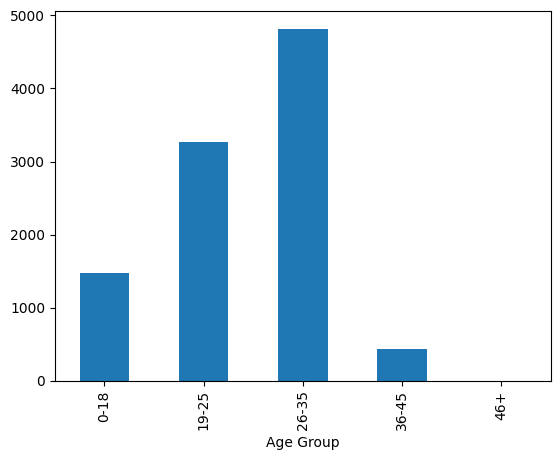

In [ ]:
df['Age Group'].value_counts().sort_index().plot(kind='bar')

In [ ]:
df['Gender'].value_counts()

,count
Gender,
Female,5078
Male,4922


<Axes: ylabel='count'>

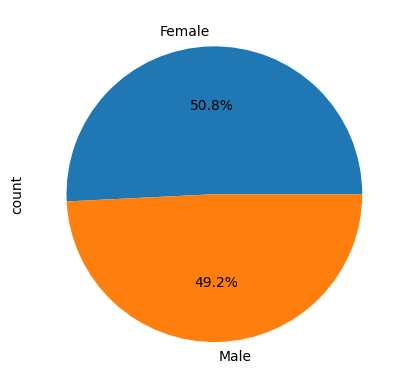

In [ ]:
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')

In [ ]:
df['CourseCategory'].value_counts()

,count
CourseCategory,
Data Science,916
Finance,864
Web Development,844
Business,833
Artificial Intelligence,829
Project Management,829
Design,827
Cybersecurity,819
Machine Learning,819


<Axes: xlabel='CourseCategory'>

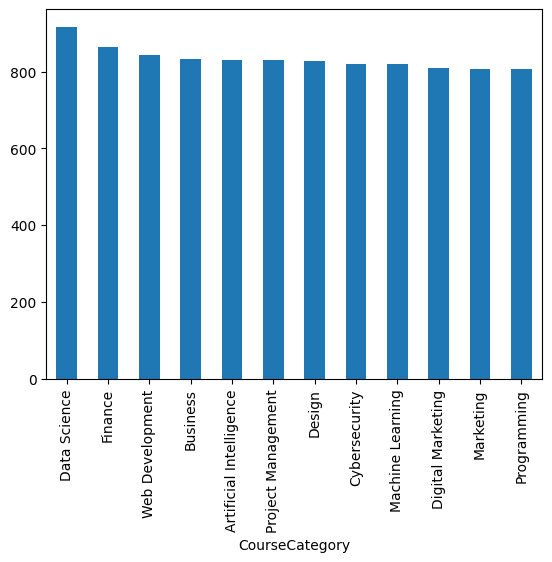

In [ ]:
df['CourseCategory'].value_counts().plot(kind='bar')

In [ ]:
df['CourseLevel'].value_counts()

,count
CourseLevel,
Beginner,3573
Advanced,3475
Intermediate,2952


<Axes: xlabel='CourseLevel'>

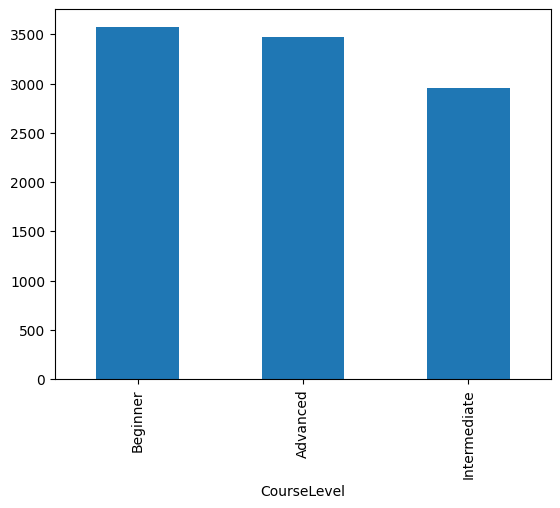

In [ ]:
df['CourseLevel'].value_counts().plot(kind='bar')

In [ ]:
pd.crosstab(df['Age Group'], df['CourseCategory'])

CourseCategory,Artificial Intelligence,Business,Cybersecurity,Data Science,Design,Digital Marketing,Finance,Machine Learning,Marketing,Programming,Project Management,Web Development
Age Group,,,,,,,,,,,,
0-18,129,120,121,114,120,127,136,120,126,109,115,132
19-25,276,265,278,300,272,263,259,263,275,274,260,287
26-35,391,415,381,464,395,385,435,395,378,386,408,387
36-45,33,33,39,38,40,33,34,41,27,37,46,38


In [ ]:
pd.crosstab(df['Gender'], df['CourseLevel'])

CourseLevel,Advanced,Beginner,Intermediate
Gender,,,
Female,1758,1811,1509
Male,1717,1762,1443


In [ ]:
df.groupby('UserID')['CourseID'].count().mean()

np.float64(3.3333333333333335)

In [ ]:
total_enrollments = df.shape[0]
print(total_enrollments)

10000


In [ ]:
total_users = df['UserID'].nunique()
print(total_users)

3000


In [ ]:
avg_courses = df.groupby('UserID')['CourseID'].count().mean()

print(round(avg_courses,2))

3.33


In [ ]:
df['CourseCategory'].mode()[0]

'Data Science'

In [ ]:
df['Age Group'].value_counts().idxmax()

'26-35'

In [ ]:
df['Gender'].value_counts(normalize=True)*100

,proportion
Gender,
Female,50.78
Male,49.22


In [ ]:
(df['CourseLevel'].value_counts(normalize=True)*100)

,proportion
CourseLevel,
Beginner,35.73
Advanced,34.75
Intermediate,29.52


In [ ]:
df['CourseCategory'].value_counts().head()

,count
CourseCategory,
Data Science,916
Finance,864
Web Development,844
Business,833
Artificial Intelligence,829


In [ ]:
df.to_csv("final_dataset.csv", index=False)